# Correcting the aberrations of a multimode fiber setup

A transmission matrix measured in the pixel basis is only as useful as the basis it is
expressed in. Projected onto the *theoretical* mode basis of the fiber it should be close
to block diagonal, coupling only modes within a near-degenerate group. In practice the
aberrations and misalignments of the optical system spoil that, and the projection loses
both energy and structure.

This notebook fits those aberrations and recovers the mode-basis transmission matrix.

**Method** — from
[*Learning and avoiding disorder in multimode fibers*](https://arxiv.org/abs/2010.14813),
M. W. Matthès, Y. Bromberg, J. de Rosny and S. M. Popoff, Phys. Rev. X **11**, 021060
(2021). A differentiable model applies a global deformation and a set of Zernike phase
screens in the Fourier and direct planes to the theoretical mode basis, and its
parameters are fitted so that the transmission matrix, once projected, keeps as much
energy as possible.

**Two numbers are tracked.** The *conversion ratio* is the fraction of the pixel-basis TM
energy surviving the projection, and is what the cost maximises. The *diagonal ratio* is
the fraction of the mode-basis TM energy sitting inside the near-degenerate blocks; it is
**not** optimised by anything, so its improvement is independent evidence that the
correction is physical.

Data is in `data/`: a measured transmission matrix and the theoretical modes on a
high-resolution grid.


In [1]:
import os
import sys
import time

import numpy as np
import matplotlib.pyplot as plt
import torch
%matplotlib inline

try:
    import PyTorchAberrations
except ImportError:          # running from a checkout without `pip install -e .`
    sys.path.insert(0, os.path.abspath('..'))

from PyTorchAberrations.scaling_functions import get_inout_modes
from PyTorchAberrations.aberration_models import AberrationModes
from PyTorchAberrations.cost_functions import norm_mode_to_norm_pix, normalize

DATA = './data'
torch.manual_seed(0)
print('torch', torch.__version__)


torch 2.13.0+cpu


## 1. Data

The transmission matrix holds two input and two output polarisations, as four quadrants.
The modes come on their own high-resolution grid, with no a-priori relation to the
modulator and camera pixels — section 2 is where that is resolved.


TM (3362, 2450)  |  55 modes on a 128x128 grid
pola_inout (2, 2)  ->  input 35x35, output 41x41


(np.float64(-0.5), np.float64(2449.5), np.float64(3361.5), np.float64(-0.5))

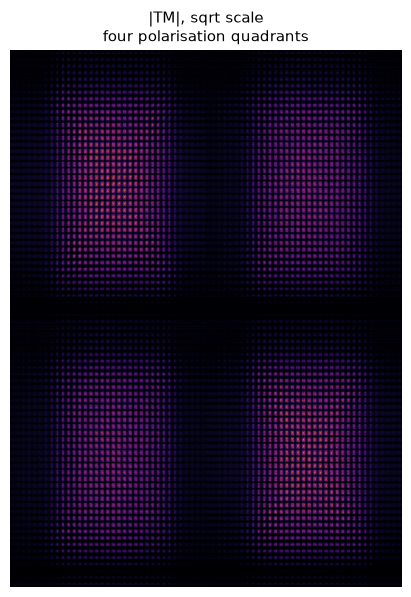

In [2]:
TM = np.load(os.path.join(DATA, 'TM_pix.npy'))
TM = TM / np.max(np.abs(TM))
TM[np.abs(TM) < 1e-3] = 0

modes_file = np.load(os.path.join(DATA, 'modes_hd.npz'))
profiles = modes_file['profiles']
mask_near_degenerate = modes_file['mask_near_degenerate']
nmodes = int(modes_file['nmodes'])

pola_inout = (2, 2)                       # two input and two output polarisations
N2_out, N2_in = TM.shape
if pola_inout[0] == 2:
    N2_in = N2_in // 2
if pola_inout[1] == 2:
    N2_out = N2_out // 2
N_in, N_out = int(np.sqrt(N2_in)), int(np.sqrt(N2_out))

n_hd = int(np.sqrt(profiles.shape[1]))
print(f'TM {TM.shape}  |  {nmodes} modes on a {n_hd}x{n_hd} grid')
print(f'pola_inout {pola_inout}  ->  input {N_in}x{N_in}, output {N_out}x{N_out}')

fig, ax = plt.subplots(figsize=(4, 8), layout='constrained')
ax.imshow(np.sqrt(np.abs(TM)), cmap='inferno')
ax.set_title('|TM|, sqrt scale\nfour polarisation quadrants', fontsize=11)
ax.axis('off')


## 2. Scaling the modes onto the pixel grids

This step comes **before** the model and is easy to overlook. `get_inout_modes` does not
assume a magnification: it measures one, by matching the RMS width of the incoherent sum
of the theoretical modes against the marginals of the measured transmission matrix. The
modes are then resampled onto the input and the output pixel grids.

The conjugation on the output side accounts for the plane being imaged inverted with
respect to the input.


modes_in (55, 1225)   modes_out (55, 1681)


Text(0.5, 0.98, 'Rescaled modes: input 35x35 (top), output 41x41 (bottom)')

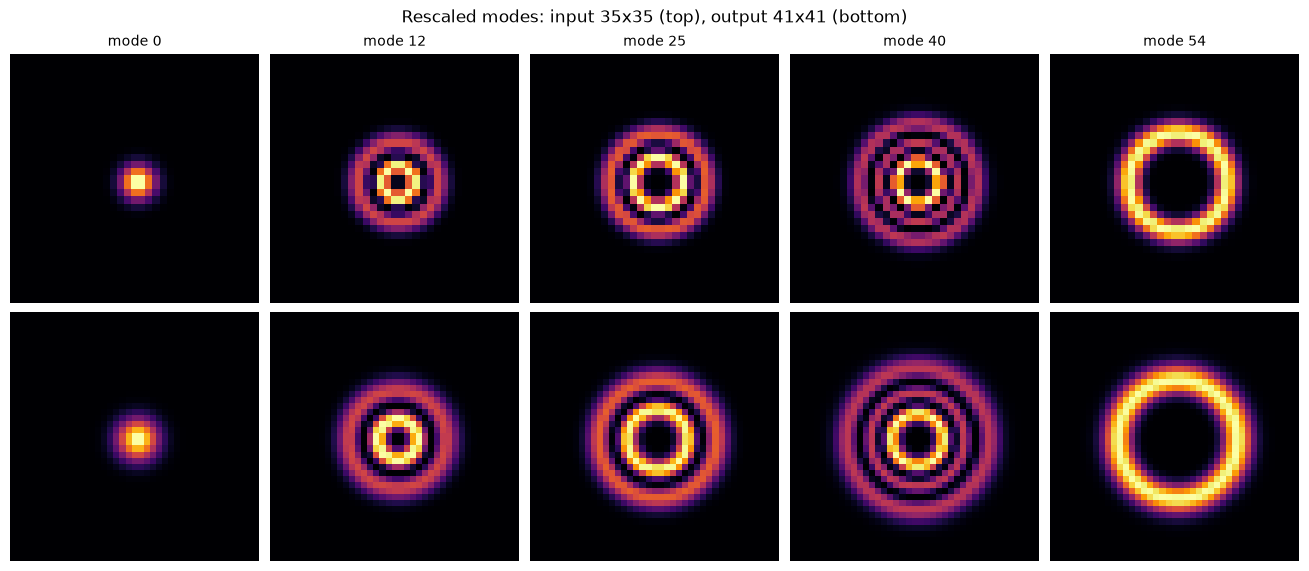

In [3]:
modes_in, modes_out = get_inout_modes(profiles, TM, pola_inout=pola_inout)
modes_out = modes_out.conj()

print(f'modes_in {modes_in.shape}   modes_out {modes_out.shape}')

fig, axes = plt.subplots(2, 5, figsize=(13, 5.6), layout='constrained')
for col, k in enumerate([0, 12, 25, 40, 54]):
    axes[0, col].imshow(np.abs(modes_in[k].reshape(N_in, N_in))**2, cmap='inferno')
    axes[0, col].set_title(f'mode {k}', fontsize=10)
    axes[1, col].imshow(np.abs(modes_out[k].reshape(N_out, N_out))**2, cmap='inferno')
for ax in axes.ravel():
    ax.axis('off')
fig.suptitle(f'Rescaled modes: input {N_in}x{N_in} (top), output {N_out}x{N_out} (bottom)')


## 3. Before correction

The correction is scalar, so a single polarisation quadrant is used.


In [4]:
TM_pix = TM[:N_out**2, :N_in**2].astype(complex)


def ratios(m_out, m_in):
    '''Conversion ratio and near-degenerate diagonal ratio of the mode-basis TM.'''
    A = m_out @ TM_pix @ m_in.conj().T
    conversion = 100 * (np.linalg.norm(A) / np.linalg.norm(TM_pix))**2
    diagonal = 100 * np.linalg.norm(A * mask_near_degenerate)**2 / np.linalg.norm(A)**2
    return conversion, diagonal, A


conv_before, diag_before, TM_modes_before = ratios(modes_out, modes_in)
print(f'before correction:  conversion {conv_before:.3f} %   diagonal {diag_before:.3f} %')


before correction:  conversion 60.184 %   diagonal 16.374 %


## 4. Fit the aberrations

`AberrationModes` holds one `Aberration` per side. Each applies a global deformation, then
a Zernike phase screen in the Fourier plane, then one in the direct plane. Every parameter
starts at a neutral value, so the untrained model returns its input unchanged.

The modes are renormalised at each step: the layers do not conserve the norm — the final
crop discards energy, a change of magnification concentrates it — and the cost is a ratio
of norms, so without this the optimiser could raise it by inflating the modes instead of
finding the right aberrations.


In [5]:
padding_coeff = 0.05                      # zero padding, for a finer Fourier sampling
list_zernike_ft = list(range(9))          # Zernike terms in the Fourier plane
list_zernike_direct = list(range(14))     # ... and in the direct plane
learning_rate = 2e-2
num_epoch = 200
deformation = 'scaling'                   # 'scaling', 'single' or 'none'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'running on {device}')

pt_modes_in = torch.from_numpy(modes_in.reshape((-1, N_in, N_in))).to(device)
pt_modes_out = torch.from_numpy(modes_out.reshape((-1, N_out, N_out))).to(device)
pt_TM = torch.from_numpy(TM_pix).to(device)

model = AberrationModes(inpoints=N_in, onpoints=N_out,
                        padding_coeff=padding_coeff,
                        list_zernike_ft=list_zernike_ft,
                        list_zernike_direct=list_zernike_direct,
                        deformation=deformation).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)


running on cpu


In [6]:
# the conversion ratio is free, being the cost itself; the diagonal ratio needs the
# projection onto the mode basis, so it is evaluated every TRACK_EVERY epochs
TRACK_EVERY = 5

evol_conversion, evol_diagonal, evol_diagonal_epoch = [], [], []
t0 = time.time()
for epoch in range(num_epoch):
    y = model(pt_modes_in, pt_modes_out)
    y = [normalize(y[0]), normalize(y[1])]
    loss = norm_mode_to_norm_pix(pt_TM, y[0], y[1], N_out, N_in)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    evol_conversion.append(100. / loss.item())
    if epoch % TRACK_EVERY == 0 or epoch == num_epoch - 1:
        _, d, _ = ratios(y[0].detach().cpu().numpy().reshape(nmodes, -1),
                         y[1].detach().cpu().numpy().reshape(nmodes, -1))
        evol_diagonal.append(d)
        evol_diagonal_epoch.append(epoch)

# the corrected change-of-basis matrices: the main output of the fit
modes_out_corr = y[0].detach().cpu().numpy().reshape(nmodes, -1)
modes_in_corr = y[1].detach().cpu().numpy().reshape(nmodes, -1)
conv_after, diag_after, TM_modes_after = ratios(modes_out_corr, modes_in_corr)

print(f'{num_epoch} epochs in {time.time()-t0:.0f} s\n')
print(f'{"":10s} {"conversion":>12} {"diagonal":>10}')
print(f'{"before":10s} {conv_before:11.3f}% {diag_before:9.3f}%')
print(f'{"after":10s} {conv_after:11.3f}% {diag_after:9.3f}%')
print(f'{"gain":10s} {conv_after-conv_before:+11.3f}  {diag_after-diag_before:+9.3f}')


200 epochs in 33 s

             conversion   diagonal
before          60.184%    16.374%
after           92.372%    89.110%
gain           +32.188    +72.736


## 5. Results

Before correction the mode-basis transmission matrix is diffuse. After, it collapses onto
the near-degenerate blocks outlined in red — which is what an aberration-free system
should give.


Text(0.5, 0.98, 'Intensity of the mode basis TM')

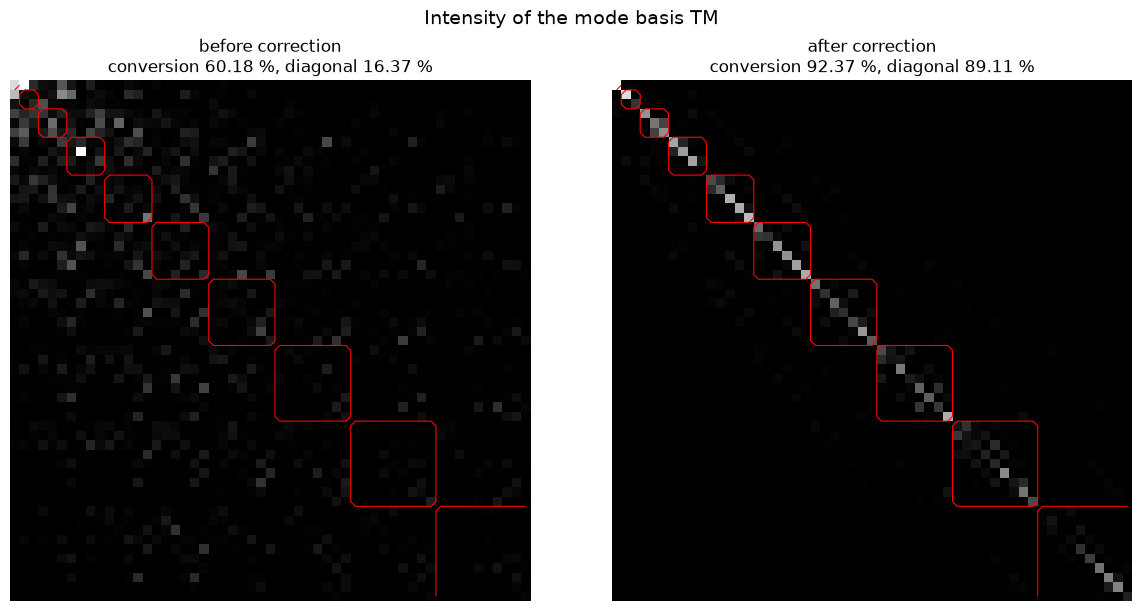

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), layout='constrained')
for ax, A, tag, c, d in [(axes[0], TM_modes_before, 'before', conv_before, diag_before),
                         (axes[1], TM_modes_after, 'after', conv_after, diag_after)]:
    ax.imshow(np.abs(A)**2, cmap='gray')
    ax.contour(mask_near_degenerate, levels=[0.5], colors='r', linewidths=0.8)
    ax.set_title(f'{tag} correction\nconversion {c:.2f} %, diagonal {d:.2f} %', fontsize=12)
    ax.axis('off')
fig.suptitle('Intensity of the mode basis TM', fontsize=14)


Text(0.5, 0.98, 'Evolution during the fit')

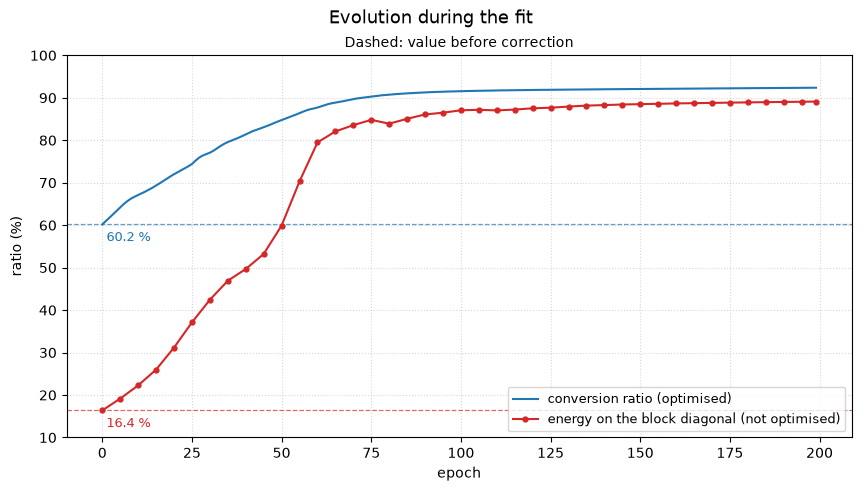

In [8]:
fig, ax = plt.subplots(figsize=(8.5, 4.8), layout='constrained')

ax.plot(evol_conversion, color='C0', label='conversion ratio (optimised)')
ax.axhline(conv_before, color='C0', ls='--', lw=0.9, alpha=0.7)
ax.annotate(f'{conv_before:.1f} %', xy=(0, conv_before), xytext=(3, -12),
            textcoords='offset points', color='C0', fontsize=9)

ax.plot(evol_diagonal_epoch, evol_diagonal, 'o-', color='C3', ms=3.5,
        label='energy on the block diagonal (not optimised)')
ax.axhline(diag_before, color='C3', ls='--', lw=0.9, alpha=0.7)
ax.annotate(f'{diag_before:.1f} %', xy=(0, diag_before), xytext=(3, -12),
            textcoords='offset points', color='C3', fontsize=9)

ax.set_xlabel('epoch')
ax.set_ylabel('ratio (%)')
ax.set_ylim(10, 100)
ax.grid(ls=':', alpha=0.5)
ax.legend(loc='lower right', fontsize=9)
ax.set_title('Dashed: value before correction', fontsize=10)
fig.suptitle('Evolution during the fit', fontsize=13)


The block-diagonal energy rises from about 16 % to about 89 % without ever entering the
cost. It also converges more slowly than the conversion ratio, which is flat well before
it settles — worth knowing if you are choosing an epoch count.

## 6. What comes out

`modes_in_corr` and `modes_out_corr` are the corrected change-of-basis matrices. Row `k`
is mode `k` written in the pixel basis, so they convert between mode amplitudes and pixel
patterns in both directions:

```python
a = modes_in_corr @ u                 # pixel field  -> mode amplitudes
u = modes_in_corr.conj().T @ a        # mode amplitudes -> pixel field
```

The fitted Zernike coefficients are in `model.abberation_input` and
`model.abberation_output`, and `PyTorchAberrations.plotting_functions.showZernikeCoefs`
displays them.

For reference, this dataset should give roughly:

| | conversion | diagonal |
|---|---|---|
| before | 60.2 % | 16.4 % |
| after | 92.4 % | 89.1 % |


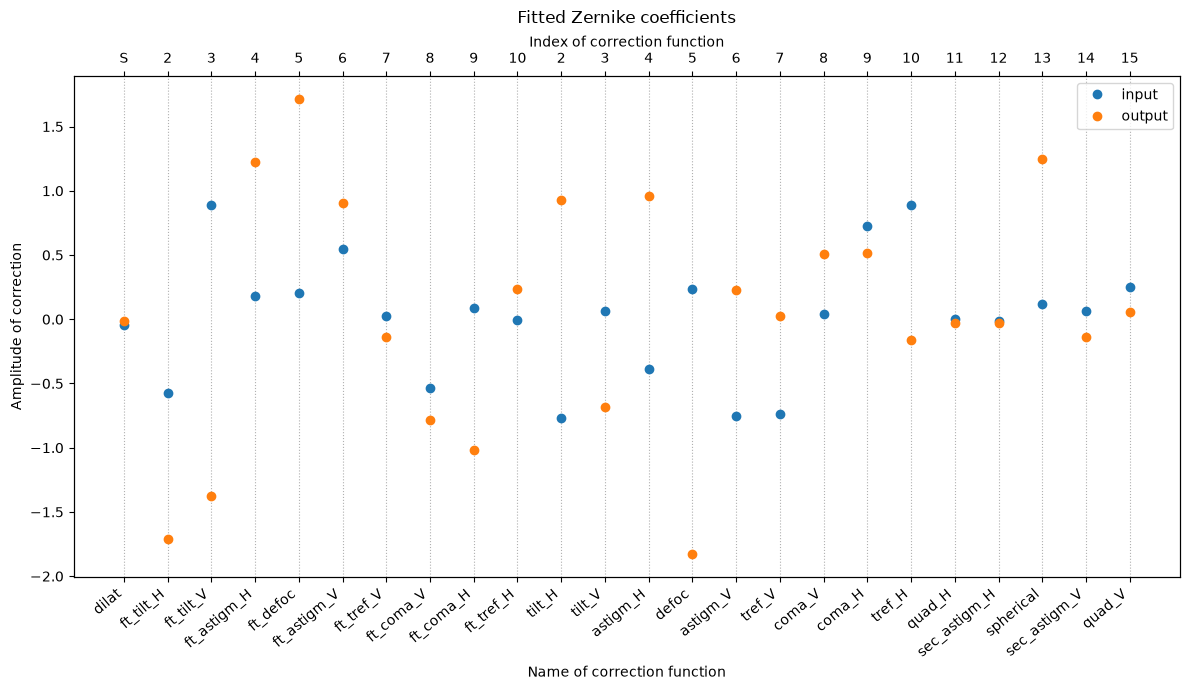

In [9]:
from PyTorchAberrations.plotting_functions import getZernikeCoefs, showZernikeCoefs

coeffs = [getZernikeCoefs(model.abberation_output.state_dict()),
          getZernikeCoefs(model.abberation_input.state_dict())]

_ = showZernikeCoefs([coeffs[1], coeffs[0]], labels=['input', 'output'],
                     title='Fitted Zernike coefficients')
